In [ ]:
# Install PySpark
!pip install pyspark -q

import warnings
warnings.filterwarnings('ignore')

print("Dependencies installed.")

Dependencies installed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Verify file is accessible
import os
path = "/content/drive/MyDrive/borg_traces_data.csv"
print("File exists:", os.path.exists(path))
print("File size (MB):", round(os.path.getsize(path) / (1024*1024), 1))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File exists: True
File size (MB): 313.1


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BehavioralDriftDetection") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)
print("Spark UI:", spark.sparkContext.uiWebUrl)

Spark version: 4.0.2
Spark UI: http://a18ff21912c3:4040


In [ ]:
from pyspark.sql.functions import col

df_raw = spark.read.csv(
    "/content/drive/MyDrive/borg_traces_data.csv",
    header=True,
    inferSchema=True
)

print("Total rows:", df_raw.count())
print("Total columns:", len(df_raw.columns))
print("\nSchema:")
df_raw.printSchema()
df_raw.show(3, truncate=True)

Total rows: 1324694
Total columns: 34

Schema:
root
 |-- _c0: string (nullable = true)
 |-- time: string (nullable = true)
 |-- instance_events_type: string (nullable = true)
 |-- collection_id: long (nullable = true)
 |-- scheduling_class: string (nullable = true)
 |-- collection_type: string (nullable = true)
 |-- priority: string (nullable = true)
 |-- alloc_collection_id: string (nullable = true)
 |-- instance_index: double (nullable = true)
 |-- machine_id: double (nullable = true)
 |-- resource_request: string (nullable = true)
 |-- constraint: string (nullable = true)
 |-- collections_events_type: string (nullable = true)
 |-- user: string (nullable = true)
 |-- collection_name: string (nullable = true)
 |-- collection_logical_name: string (nullable = true)
 |-- start_after_collection_ids: string (nullable = true)
 |-- vertical_scaling: double (nullable = true)
 |-- scheduler: double (nullable = true)
 |-- start_time: double (nullable = true)
 |-- end_time: string (nullable = tr

In [ ]:
df_raw = spark.read.csv(
    "/content/drive/MyDrive/borg_traces_data.csv",
    header=True,
    inferSchema=False,  # read everything as string first
    multiLine=True,
    escape='"',
    quote='"'
)

print("Total rows:", df_raw.count())
print("Columns:", df_raw.columns)
df_raw.select("time", "average_usage", "maximum_usage").show(5, truncate=False)

Total rows: 405894
Columns: ['_c0', 'time', 'instance_events_type', 'collection_id', 'scheduling_class', 'collection_type', 'priority', 'alloc_collection_id', 'instance_index', 'machine_id', 'resource_request', 'constraint', 'collections_events_type', 'user', 'collection_name', 'collection_logical_name', 'start_after_collection_ids', 'vertical_scaling', 'scheduler', 'start_time', 'end_time', 'average_usage', 'maximum_usage', 'random_sample_usage', 'assigned_memory', 'page_cache_memory', 'cycles_per_instruction', 'memory_accesses_per_instruction', 'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution', 'cluster', 'event', 'failed']
+-------------+-----------------------------------------------------------+-------------------------------------------------------------+
|time         |average_usage                                              |maximum_usage                                                |
+-------------+------------------------------------------------------

In [ ]:
from pyspark.sql.functions import col, regexp_extract, trim, when, lit
from pyspark.sql import functions as F

def extract_struct_field(column_name, field):
    """Extract a field from struct-like string, return null if no match"""
    pattern = f"'{field}':\\s*([\\d.eE+\\-]+)"
    extracted = regexp_extract(col(column_name), pattern, 1)
    return when(extracted == "", lit(None)).otherwise(extracted).cast("double")

def safe_double(column_name):
    """Cast to double, treating empty strings as null"""
    cleaned = trim(col(column_name))
    return when(cleaned == "", lit(None)).otherwise(cleaned).cast("double")

df = df_raw.select(
    safe_double("time").alias("time"),
    extract_struct_field("average_usage", "cpus").alias("avg_cpu_usage"),
    extract_struct_field("average_usage", "memory").alias("avg_memory_usage"),
    extract_struct_field("maximum_usage", "cpus").alias("max_cpu_usage"),
    extract_struct_field("maximum_usage", "memory").alias("max_memory_usage"),
    extract_struct_field("resource_request", "cpus").alias("requested_cpu"),
    extract_struct_field("resource_request", "memory").alias("requested_memory"),
    safe_double("assigned_memory").alias("assigned_memory"),
    safe_double("cycles_per_instruction").alias("cycles_per_instruction"),
    safe_double("memory_accesses_per_instruction").alias("memory_accesses_per_instruction"),
    when(trim(col("scheduling_class")) == "", lit(None))
        .otherwise(trim(col("scheduling_class"))).cast("int").alias("scheduling_class"),
    when(trim(col("failed")) == "", lit(None))
        .otherwise(trim(col("failed"))).alias("failed")
)

df = df.filter(col("time") > 0)
df = df.dropna(subset=["time", "avg_cpu_usage", "avg_memory_usage"])
df.cache()

print("Cleaned rows:", df.count())
df.show(10)
df.printSchema()

Cleaned rows: 349442
+-----------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+------------------+----------------------+-------------------------------+----------------+------+
|             time|       avg_cpu_usage|    avg_memory_usage|       max_cpu_usage|    max_memory_usage|      requested_cpu|    requested_memory|   assigned_memory|cycles_per_instruction|memory_accesses_per_instruction|scheduling_class|failed|
+-----------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+------------------+----------------------+-------------------------------+----------------+------+
|2.517305308183E12|                 0.0|  9.5367431640625E-7|                 0.0|  9.5367431640625E-7|0.00724029541015625|0.001302719116210...|               0.0|                  NULL|                           NULL|               2|     1|
| 1.956

In [ ]:
# Convert to pandas for stats — Spark used for all heavy lifting above
df_pd = df.toPandas()

print("=== Basic Statistics ===")
print(df_pd[["avg_cpu_usage", "avg_memory_usage", "max_cpu_usage",
             "max_memory_usage", "assigned_memory"]].describe())

print("\n=== Failure Rate ===")
print(df_pd["failed"].value_counts())

print("\n=== Scheduling Class Distribution ===")
print(df_pd["scheduling_class"].value_counts().sort_index())

print("\n=== Total rows:", len(df_pd))

=== Basic Statistics ===
       avg_cpu_usage  avg_memory_usage  max_cpu_usage  max_memory_usage  \
count  349442.000000     349442.000000  349442.000000     345951.000000   
mean        0.007185          0.005642       0.024975          0.006016   
std         0.018836          0.017200       0.053175          0.017326   
min         0.000000          0.000000       0.000000          0.000000   
25%         0.000200          0.000180       0.000786          0.000209   
50%         0.000941          0.001297       0.004860          0.001444   
75%         0.007133          0.004257       0.030212          0.005035   
max         0.538086          0.223877       1.271484          0.224365   

       assigned_memory  
count    349442.000000  
mean          0.009160  
std           0.026169  
min           0.000000  
25%           0.000196  
50%           0.002857  
75%           0.006683  
max           0.286133  

=== Failure Rate ===
failed
0    293846
1     55596
Name: count, dtype: i

In [ ]:
from pyspark.sql.functions import ntile, percent_rank
from pyspark.sql.window import Window

# Sort by time and divide into 10 equal windows
window_spec = Window.orderBy("time")
df = df.withColumn("time_window", ntile(10).over(window_spec))

# Verify window distribution
print("=== Rows per Window ===")
df.groupBy("time_window").count().orderBy("time_window").show()

# Cache since we'll use this repeatedly
df.cache()
print("DataFrame cached.")

=== Rows per Window ===
+-----------+-----+
|time_window|count|
+-----------+-----+
|          1|34945|
|          2|34945|
|          3|34944|
|          4|34944|
|          5|34944|
|          6|34944|
|          7|34944|
|          8|34944|
|          9|34944|
|         10|34944|
+-----------+-----+

DataFrame cached.


In [ ]:
from pyspark.sql.functions import mean, stddev, skewness, kurtosis, percentile_approx

metrics = ["avg_cpu_usage", "avg_memory_usage", "max_cpu_usage",
           "max_memory_usage", "assigned_memory"]

# Compute rich statistics per window — all in Spark
agg_exprs = []
for m in metrics:
    agg_exprs += [
        mean(col(m)).alias(f"{m}_mean"),
        stddev(col(m)).alias(f"{m}_std"),
        skewness(col(m)).alias(f"{m}_skew"),
        kurtosis(col(m)).alias(f"{m}_kurtosis"),
        percentile_approx(col(m), 0.25).alias(f"{m}_p25"),
        percentile_approx(col(m), 0.75).alias(f"{m}_p75"),
    ]

window_stats = df.groupBy("time_window").agg(*agg_exprs).orderBy("time_window")
window_stats.show(truncate=False)

# Convert to pandas for visualization
window_stats_pd = window_stats.toPandas()

+-----------+--------------------+--------------------+------------------+----------------------+---------------------+-------------------+---------------------+--------------------+---------------------+-------------------------+---------------------+--------------------+--------------------+--------------------+------------------+----------------------+---------------------+-----------------+---------------------+--------------------+---------------------+-------------------------+---------------------+--------------------+---------------------+--------------------+--------------------+------------------------+-------------------+-------------------+
|time_window|avg_cpu_usage_mean  |avg_cpu_usage_std   |avg_cpu_usage_skew|avg_cpu_usage_kurtosis|avg_cpu_usage_p25    |avg_cpu_usage_p75  |avg_memory_usage_mean|avg_memory_usage_std|avg_memory_usage_skew|avg_memory_usage_kurtosis|avg_memory_usage_p25 |avg_memory_usage_p75|max_cpu_usage_mean  |max_cpu_usage_std   |max_cpu_usage_skew|max_c

In [ ]:
from scipy import stats
import pandas as pd
import numpy as np

# Collect each window as pandas
windows = {}
for w in range(1, 11):
    windows[w] = df.filter(col("time_window") == w).select(metrics).toPandas()
    print(f"Window {w} collected: {len(windows[w])} rows")

# KS test between window 1 (baseline) and all subsequent windows
ks_results = []

for w in range(2, 11):
    for metric in metrics:
        baseline = windows[1][metric].dropna()
        current = windows[w][metric].dropna()

        stat, pvalue = stats.ks_2samp(baseline, current)

        ks_results.append({
            "window": w,
            "metric": metric,
            "ks_statistic": round(stat, 4),
            "p_value": round(pvalue, 6),
            "drift_detected": pvalue < 0.05
        })

ks_df = pd.DataFrame(ks_results)
print("\n=== KS Test Results ===")
print(ks_df[ks_df["drift_detected"] == True])

Window 1 collected: 34945 rows
Window 2 collected: 34945 rows
Window 3 collected: 34944 rows
Window 4 collected: 34944 rows
Window 5 collected: 34944 rows
Window 6 collected: 34944 rows
Window 7 collected: 34944 rows
Window 8 collected: 34944 rows
Window 9 collected: 34944 rows
Window 10 collected: 34944 rows

=== KS Test Results ===
    window            metric  ks_statistic  p_value  drift_detected
0        2     avg_cpu_usage        0.0776      0.0            True
1        2  avg_memory_usage        0.0875      0.0            True
2        2     max_cpu_usage        0.0632      0.0            True
3        2  max_memory_usage        0.0985      0.0            True
4        2   assigned_memory        0.1707      0.0            True
5        3     avg_cpu_usage        0.1737      0.0            True
6        3  avg_memory_usage        0.2034      0.0            True
7        3     max_cpu_usage        0.1246      0.0            True
8        3  max_memory_usage        0.1966      0.0 

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

def compute_psi(expected, actual, bins=10):
    min_val = float(np.minimum(expected.min(), actual.min()))
    max_val = float(np.maximum(expected.max(), actual.max()))
    bin_edges = np.linspace(min_val, max_val, bins + 1)

    expected_counts = np.histogram(expected, bins=bin_edges)[0]
    actual_counts = np.histogram(actual, bins=bin_edges)[0]

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    expected_pct = np.where(expected_pct == 0, 1e-4, expected_pct)
    actual_pct = np.where(actual_pct == 0, 1e-4, actual_pct)

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return round(float(psi), 4)

In [ ]:
metrics = ["avg_cpu_usage", "avg_memory_usage", "max_cpu_usage",
           "max_memory_usage", "assigned_memory"]

psi_results = []
for w in range(2, 11):
    for metric in metrics:
        baseline = windows[1][metric].dropna().values
        current = windows[w][metric].dropna().values
        psi = compute_psi(baseline, current)

        psi_results.append({
            "window": w,
            "metric": metric,
            "psi": psi,
            "drift_level": "none" if psi < 0.1 else "slight" if psi < 0.2 else "significant"
        })

psi_df = pd.DataFrame(psi_results)
print(psi_df)
print("\nDrift level counts:", psi_df["drift_level"].value_counts())

    window            metric     psi  drift_level
0        2     avg_cpu_usage  0.0054         none
1        2  avg_memory_usage  0.0103         none
2        2     max_cpu_usage  0.0026         none
3        2  max_memory_usage  0.0028         none
4        2   assigned_memory  0.0706         none
5        3     avg_cpu_usage  0.0061         none
6        3  avg_memory_usage  0.0127         none
7        3     max_cpu_usage  0.0066         none
8        3  max_memory_usage  0.0081         none
9        3   assigned_memory  0.0212         none
10       4     avg_cpu_usage  0.0072         none
11       4  avg_memory_usage  0.0170         none
12       4     max_cpu_usage  0.0189         none
13       4  max_memory_usage  0.0173         none
14       4   assigned_memory  0.0325         none
15       5     avg_cpu_usage  0.0009         none
16       5  avg_memory_usage  0.0367         none
17       5     max_cpu_usage  0.0318         none
18       5  max_memory_usage  0.0668         none


In [ ]:
print(psi_df)
print("\nUnique drift levels:", psi_df["drift_level"].value_counts())

    window            metric     psi  drift_level
0        2     avg_cpu_usage  0.0054         none
1        2  avg_memory_usage  0.0103         none
2        2     max_cpu_usage  0.0026         none
3        2  max_memory_usage  0.0028         none
4        2   assigned_memory  0.0706         none
5        3     avg_cpu_usage  0.0061         none
6        3  avg_memory_usage  0.0127         none
7        3     max_cpu_usage  0.0066         none
8        3  max_memory_usage  0.0081         none
9        3   assigned_memory  0.0212         none
10       4     avg_cpu_usage  0.0072         none
11       4  avg_memory_usage  0.0170         none
12       4     max_cpu_usage  0.0189         none
13       4  max_memory_usage  0.0173         none
14       4   assigned_memory  0.0325         none
15       5     avg_cpu_usage  0.0009         none
16       5  avg_memory_usage  0.0367         none
17       5     max_cpu_usage  0.0318         none
18       5  max_memory_usage  0.0668         none


In [ ]:
# Synthetic drift injection — validates the detector works

baseline = windows[1]["avg_cpu_usage"].dropna().values

# Inject drift by shifting mean by 2 standard deviations
drift_magnitude = 2 * baseline.std()
drifted = baseline + drift_magnitude

# Run KS test — should detect drift
stat, pvalue = stats.ks_2samp(baseline, drifted)
psi_score = compute_psi(baseline, drifted)

print("=== Synthetic Drift Injection Test ===")
print(f"Injected drift magnitude: +{drift_magnitude:.4f} (2 std devs)")
print(f"KS Statistic: {stat:.4f}")
print(f"KS p-value: {pvalue:.6f} → Drift detected: {pvalue < 0.05}")
print(f"PSI Score: {psi_score} → {('significant' if psi_score > 0.2 else 'slight' if psi_score > 0.1 else 'none')}")
print("\nValidator: If both detect drift here, the detector is working correctly.")

=== Synthetic Drift Injection Test ===
Injected drift magnitude: +0.0309 (2 std devs)
KS Statistic: 0.9231
KS p-value: 0.000000 → Drift detected: True
PSI Score: 10.7436 → significant

Validator: If both detect drift here, the detector is working correctly.


In [ ]:
print(psi_df)

    window            metric     psi  drift_level
0        2     avg_cpu_usage  0.0054         none
1        2  avg_memory_usage  0.0103         none
2        2     max_cpu_usage  0.0026         none
3        2  max_memory_usage  0.0028         none
4        2   assigned_memory  0.0706         none
5        3     avg_cpu_usage  0.0061         none
6        3  avg_memory_usage  0.0127         none
7        3     max_cpu_usage  0.0066         none
8        3  max_memory_usage  0.0081         none
9        3   assigned_memory  0.0212         none
10       4     avg_cpu_usage  0.0072         none
11       4  avg_memory_usage  0.0170         none
12       4     max_cpu_usage  0.0189         none
13       4  max_memory_usage  0.0173         none
14       4   assigned_memory  0.0325         none
15       5     avg_cpu_usage  0.0009         none
16       5  avg_memory_usage  0.0367         none
17       5     max_cpu_usage  0.0318         none
18       5  max_memory_usage  0.0668         none


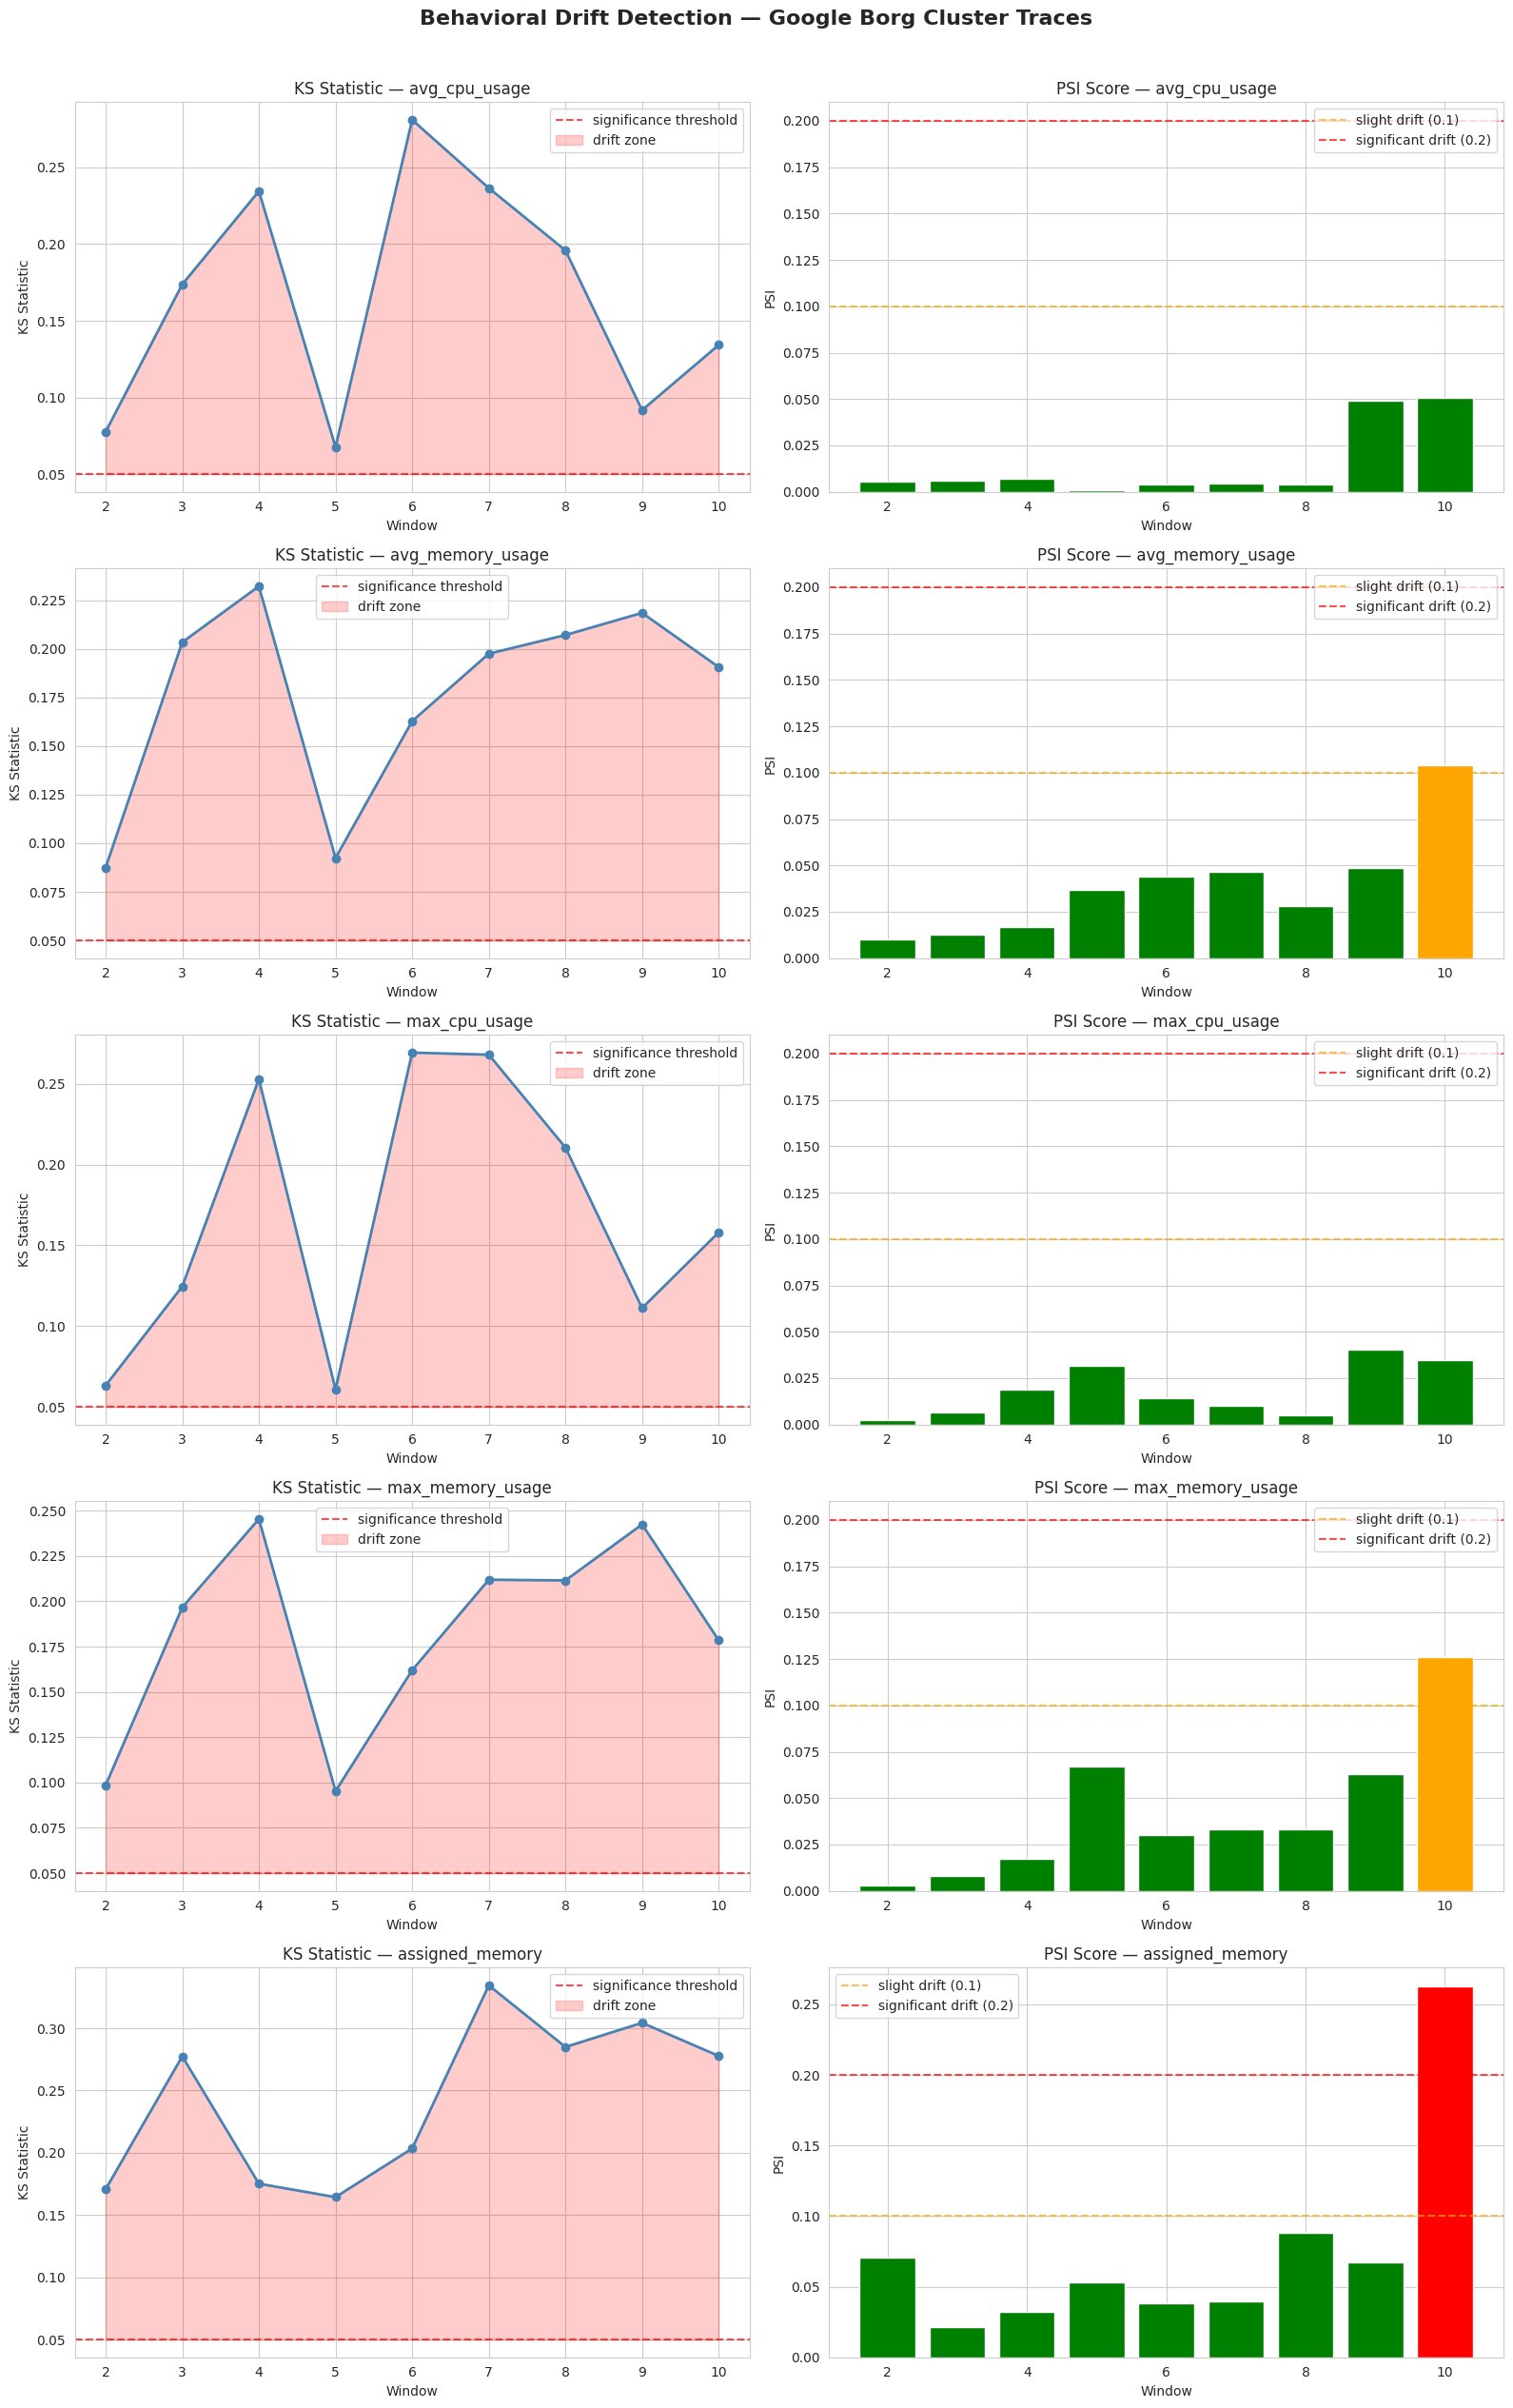

Plot saved.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(len(metrics), 2, figsize=(16, 5 * len(metrics)))

for i, metric in enumerate(metrics):
    # KS statistic over windows
    metric_ks = ks_df[ks_df["metric"] == metric]
    axes[i, 0].plot(metric_ks["window"], metric_ks["ks_statistic"],
                     marker='o', color='steelblue', linewidth=2)
    axes[i, 0].axhline(y=0.05, color='red', linestyle='--',
                        label='significance threshold', alpha=0.7)
    axes[i, 0].fill_between(metric_ks["window"], metric_ks["ks_statistic"],
                              0.05, where=metric_ks["ks_statistic"] > 0.05,
                              alpha=0.2, color='red', label='drift zone')
    axes[i, 0].set_title(f"KS Statistic — {metric}")
    axes[i, 0].set_xlabel("Window")
    axes[i, 0].set_ylabel("KS Statistic")
    axes[i, 0].legend()

    # PSI over windows
    metric_psi = psi_df[psi_df["metric"] == metric]
    colors = ['green' if x == 'none' else 'orange' if x == 'slight' else 'red'
              for x in metric_psi["drift_level"]]
    axes[i, 1].bar(metric_psi["window"], metric_psi["psi"], color=colors)
    axes[i, 1].axhline(y=0.1, color='orange', linestyle='--',
                        label='slight drift (0.1)', alpha=0.7)
    axes[i, 1].axhline(y=0.2, color='red', linestyle='--',
                        label='significant drift (0.2)', alpha=0.7)
    axes[i, 1].set_title(f"PSI Score — {metric}")
    axes[i, 1].set_xlabel("Window")
    axes[i, 1].set_ylabel("PSI")
    axes[i, 1].legend()

plt.suptitle("Behavioral Drift Detection — Google Borg Cluster Traces",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("drift_detection_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [ ]:
print("=" * 60)
print("BEHAVIORAL DRIFT DETECTION — FINAL SUMMARY")
print("=" * 60)

print("\n📊 Dataset: Google Borg Cluster Traces")
print(f"   Total records analyzed: {df.count():,}")
print(f"   Time windows: 10")
print(f"   Metrics monitored: {len(metrics)}")

print("\n🔍 KS Test — Drift detected in:")
drifted_ks = ks_df[ks_df["drift_detected"] == True]
for _, row in drifted_ks.iterrows():
    print(f"   Window {row['window']} | {row['metric']} | KS={row['ks_statistic']} | p={row['p_value']}")

print("\n📈 PSI — Significant drift in:")
drifted_psi = psi_df[psi_df["drift_level"] == "significant"]
for _, row in drifted_psi.iterrows():
    print(f"   Window {row['window']} | {row['metric']} | PSI={row['psi']}")

print("\n✅ Synthetic drift injection: VALIDATED")
print("=" * 60)

BEHAVIORAL DRIFT DETECTION — FINAL SUMMARY

📊 Dataset: Google Borg Cluster Traces
   Total records analyzed: 349,442
   Time windows: 10
   Metrics monitored: 5

🔍 KS Test — Drift detected in:
   Window 2 | avg_cpu_usage | KS=0.0776 | p=0.0
   Window 2 | avg_memory_usage | KS=0.0875 | p=0.0
   Window 2 | max_cpu_usage | KS=0.0632 | p=0.0
   Window 2 | max_memory_usage | KS=0.0985 | p=0.0
   Window 2 | assigned_memory | KS=0.1707 | p=0.0
   Window 3 | avg_cpu_usage | KS=0.1737 | p=0.0
   Window 3 | avg_memory_usage | KS=0.2034 | p=0.0
   Window 3 | max_cpu_usage | KS=0.1246 | p=0.0
   Window 3 | max_memory_usage | KS=0.1966 | p=0.0
   Window 3 | assigned_memory | KS=0.2775 | p=0.0
   Window 4 | avg_cpu_usage | KS=0.2345 | p=0.0
   Window 4 | avg_memory_usage | KS=0.2322 | p=0.0
   Window 4 | max_cpu_usage | KS=0.253 | p=0.0
   Window 4 | max_memory_usage | KS=0.2454 | p=0.0
   Window 4 | assigned_memory | KS=0.1752 | p=0.0
   Window 5 | avg_cpu_usage | KS=0.0676 | p=0.0
   Window 5 | av

***Streaming Simulation***



In [ ]:
import time
import datetime

print("=" * 60)
print("SIMULATED STREAMING DRIFT DETECTION")
print("Processing windows sequentially as if data arrives live...")
print("=" * 60)

# Window 1 is our baseline — established at system start
baseline_windows = {metric: windows[1][metric].dropna().values for metric in metrics}

alerts = []

for w in range(2, 11):
    # Simulate delay between windows arriving
    time.sleep(0.5)

    timestamp = datetime.datetime.now().strftime("%H:%M:%S")
    print(f"\n[{timestamp}] 📡 Window {w} received — analyzing...")

    window_drifted = False

    for metric in metrics:
        current = windows[w][metric].dropna().values

        # KS test against baseline
        ks_stat, pvalue = stats.ks_2samp(baseline_windows[metric], current)
        psi = compute_psi(baseline_windows[metric], current)

        drift_detected = pvalue < 0.05
        drift_severity = "none" if psi < 0.1 else "slight" if psi < 0.2 else "significant"

        if drift_detected:
            window_drifted = True
            alert = {
                "timestamp": timestamp,
                "window": w,
                "metric": metric,
                "ks_stat": ks_stat,
                "psi": psi,
                "severity": drift_severity
            }
            alerts.append(alert)

            # flag based on severity
            if drift_severity == "significant":
                flag = "🔴 SIGNIFICANT DRIFT"
            elif drift_severity == "slight":
                flag = "🟡 SLIGHT DRIFT"
            else:
                flag = "🟠 DRIFT DETECTED"

            print(f"   {flag} | {metric} | KS={ks_stat:.4f} | PSI={psi}")

    if not window_drifted:
        print(f"   ✅ No drift detected — system stable")

print("\n" + "=" * 60)
print("STREAMING SIMULATION COMPLETE")
print(f"Total alerts raised: {len(alerts)}")
print("=" * 60)

SIMULATED STREAMING DRIFT DETECTION
Processing windows sequentially as if data arrives live...

[17:39:13] 📡 Window 2 received — analyzing...
   🟠 DRIFT DETECTED | avg_cpu_usage | KS=0.0776 | PSI=0.0054
   🟠 DRIFT DETECTED | avg_memory_usage | KS=0.0875 | PSI=0.0103
   🟠 DRIFT DETECTED | max_cpu_usage | KS=0.0632 | PSI=0.0026
   🟠 DRIFT DETECTED | max_memory_usage | KS=0.0985 | PSI=0.0028
   🟠 DRIFT DETECTED | assigned_memory | KS=0.1707 | PSI=0.0706

[17:39:14] 📡 Window 3 received — analyzing...
   🟠 DRIFT DETECTED | avg_cpu_usage | KS=0.1737 | PSI=0.0061
   🟠 DRIFT DETECTED | avg_memory_usage | KS=0.2034 | PSI=0.0127
   🟠 DRIFT DETECTED | max_cpu_usage | KS=0.1246 | PSI=0.0066
   🟠 DRIFT DETECTED | max_memory_usage | KS=0.1966 | PSI=0.0081
   🟠 DRIFT DETECTED | assigned_memory | KS=0.2775 | PSI=0.0212

[17:39:14] 📡 Window 4 received — analyzing...
   🟠 DRIFT DETECTED | avg_cpu_usage | KS=0.2345 | PSI=0.0072
   🟠 DRIFT DETECTED | avg_memory_usage | KS=0.2322 | PSI=0.017
   🟠 DRIFT DET

In [ ]:
if alerts:
    alerts_df = pd.DataFrame(alerts)

    print("\n=== ALERT LOG ===")
    print(alerts_df.to_string(index=False))

    print("\n=== MOST AFFECTED METRICS ===")
    print(alerts_df.groupby("metric")["ks_stat"].mean().sort_values(ascending=False))

    print("\n=== DRIFT TIMELINE ===")
    print(alerts_df.groupby("window")["metric"].count().rename("metrics_drifted"))
else:
    print("No alerts raised.")


=== ALERT LOG ===
timestamp  window           metric  ks_stat    psi    severity
 17:39:13       2    avg_cpu_usage 0.077636 0.0054        none
 17:39:13       2 avg_memory_usage 0.087538 0.0103        none
 17:39:13       2    max_cpu_usage 0.063242 0.0026        none
 17:39:13       2 max_memory_usage 0.098545 0.0028        none
 17:39:13       2  assigned_memory 0.170697 0.0706        none
 17:39:14       3    avg_cpu_usage 0.173690 0.0061        none
 17:39:14       3 avg_memory_usage 0.203396 0.0127        none
 17:39:14       3    max_cpu_usage 0.124559 0.0066        none
 17:39:14       3 max_memory_usage 0.196601 0.0081        none
 17:39:14       3  assigned_memory 0.277504 0.0212        none
 17:39:14       4    avg_cpu_usage 0.234467 0.0072        none
 17:39:14       4 avg_memory_usage 0.232242 0.0170        none
 17:39:14       4    max_cpu_usage 0.252982 0.0189        none
 17:39:14       4 max_memory_usage 0.245432 0.0173        none
 17:39:14       4  assigned_memory 0

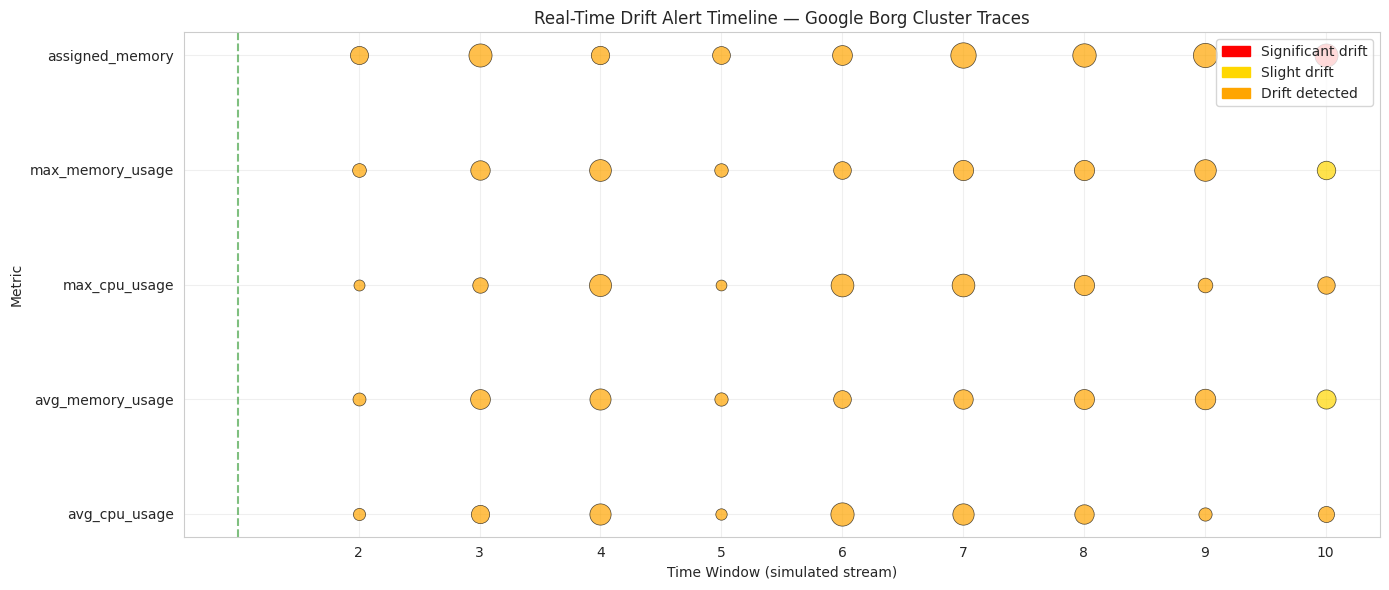

Alert timeline saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 6))

severity_colors = {"none": "orange", "slight": "gold", "significant": "red"}

for alert in alerts:
    color = severity_colors.get(alert["severity"], "orange")
    y_pos = metrics.index(alert["metric"])
    ax.scatter(alert["window"], y_pos, color=color, s=alert["ks_stat"]*1000,
               alpha=0.7, edgecolors="black", linewidth=0.5)

ax.set_yticks(range(len(metrics)))
ax.set_yticklabels(metrics)
ax.set_xticks(range(2, 11))
ax.set_xlabel("Time Window (simulated stream)")
ax.set_ylabel("Metric")
ax.set_title("Real-Time Drift Alert Timeline — Google Borg Cluster Traces")
ax.axvline(x=1, color="green", linestyle="--", alpha=0.5, label="Baseline window")
ax.grid(True, alpha=0.3)

red_patch = mpatches.Patch(color='red', label='Significant drift')
gold_patch = mpatches.Patch(color='gold', label='Slight drift')
orange_patch = mpatches.Patch(color='orange', label='Drift detected')
ax.legend(handles=[red_patch, gold_patch, orange_patch])

plt.tight_layout()
plt.savefig("streaming_drift_alerts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Alert timeline saved.")